# T09 — Visco-plasticity and shear bands: what localises, and what only looks like it

**Cluster D — Part 3, lithospheric deformation.** Requires the container.

Everything up to here has been viscous. Rock is not: near the surface it is cold,
and cold rock breaks. A viscous model of the upper crust will smear a fault over
a hundred kilometres because it has no mechanism to concentrate deformation.
Adding a **yield stress** gives it one, and the result is a *shear band* — a
narrow zone doing almost all of the work.

This is also where the suite reaches the edge of what is comfortable. The
governing equations become genuinely nonlinear, Newton's method stops converging
from a cold start, and — the part worth staying for — several of the numbers you
would naturally quote from the output **do not converge under mesh refinement at
all**. Learning which ones do is most of the skill.

The vehicle is the shear-band benchmark of
[Spiegelman, May & Wilson (2016)](https://doi.org/10.1002/2015GC006228), which
G-ADOPT ships as its `Drucker_Prager` demo. We use it twice, in shortening and
in extension, because **the two experiments differ by one sign.**

## Learning objectives

1. Combine a ductile and a brittle rheology, and say why the combination is the *weaker* of the two.
2. Explain why Newton fails from a cold start here, and what the Picard warm-up is for.
3. Measure the dip of a shear band and check it against Coulomb, Roscoe and Arthur theory.
4. Distinguish a mesh-convergent diagnostic from one that is really reporting the mesh.

## Prerequisites and runtime

* T04 (Stokes), T07 (G-ADOPT). **Requires the container.**
* **Measured runtime: about 3 minutes** at the defaults below.

In [1]:
# === USER CONFIGURATION ===
NX, NY = 128, 64          # production resolution for the two headline runs
SWEEP = (64, 128)         # resolutions for the convergence table (192, 256 quoted)
NOTCH_NX = 128            # seed-width experiment; coarser makes the peak noisy
ARROW_EVERY = 12

In [2]:
import json
import os
import subprocess
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from geodynkit import plotting

DRIVER = os.path.join("..", "tools", "gadopt_lithosphere_case.py")
OUT = "lith"


def run(mode, nx=NX, ny=None, **kw):
    """Run the driver once and return its RESULT dict."""
    ny = ny or nx // 2
    tag = f"{OUT}_{mode}_{nx}" + "".join(f"_{k}{v}" for k, v in kw.items())
    cmd = [sys.executable, DRIVER, "--mode", mode, "--nx", str(nx),
           "--ny", str(ny), "--out", f"{tag}.npz"]
    for k, v in kw.items():
        cmd += [f"--{k.replace('_', '-')}", str(v)]
    proc = subprocess.run(cmd, capture_output=True, text=True)
    for line in proc.stdout.splitlines():
        if line.startswith("RESULT "):
            return json.loads(line[len("RESULT "):])
    raise RuntimeError(f"no result from {' '.join(cmd)}:\n{proc.stderr[-1200:]}")

## 1. The rheology, in three lines

The ductile branch is an ordinary viscosity $\mu_1$. The brittle branch is a
**Drucker–Prager** yield stress that grows with pressure, because rock is harder
to break when you squeeze it:

$$\sigma_y = C\cos\phi + P\sin\phi$$

with cohesion $C = 100$ MPa and friction angle $\phi = 30°$. Yielding is written
as an equivalent viscosity by asking what viscosity would produce exactly the
yield stress at the local strain rate:

$$\mu_{\text{plast}} = \frac{\sigma_y}{2\dot\varepsilon_{II}}$$

and the two are combined harmonically,

$$\frac{1}{\mu_{\text{eff}}} = \frac{1}{\mu_1} + \frac{1}{\mu_{\text{plast}}},$$

which is a smooth stand-in for "whichever mechanism is easier wins". Take a
moment on the middle equation, because it is the source of every numerical
difficulty in this notebook: $\mu_{\text{plast}}$ has $\dot\varepsilon_{II}$ in
the **denominator**. Deform faster and the material gets weaker; get weaker and
it deforms faster. That feedback is exactly what makes a shear band, and exactly
what makes the equations hard to solve.

It also means the viscosity is *undefined* at rest. At $u = 0$ the strain rate is
zero and $\mu_{\text{plast}} = \infty$ — you cannot simply start iterating from
nothing.

### The geometry

A 120 × 30 km box, a strong layer ($10^{23}$ Pa s) over a weak substrate
($10^{21}$ Pa s), pulled or pushed at 5 mm/yr, with a small **notch** cut into the
layer interface at the centre. The notch matters: without it the problem is
translation-invariant along strike and bands appear only where round-off noise
happens to break the symmetry — which teaches a student that shear zones come
from floating point.

## 2. Two experiments, one sign

```python
sgn = 1.0 if mode == "shortening" else -1.0
bcs = {left: {"ux": sgn * 1}, right: {"ux": -sgn * 1}, bottom: {"uy": 0}}
```

Material driven inward shortens; driven outward, it rifts. Nothing else in the
setup changes — same rheology, same notch, same solver. Any difference in the
answer is physics, not configuration, and that is worth more than two separately
tuned models would be.

In [3]:
res = {m: run(m) for m in ("shortening", "extension")}
for m, r in res.items():
    print(f"{m:>11}: Picard {r['picard_iterations']:>2} iters "
          f"({r['picard_seconds']:>5.1f} s), Newton converged={r['newton_converged']} "
          f"({r['newton_seconds']:.1f} s), peak eps_II {r['strain_rate_max']:.2f}")

 shortening: Picard 18 iters (  9.3 s), Newton converged=True (1.8 s), peak eps_II 3.62
  extension: Picard 34 iters ( 18.4 s), Newton converged=True (1.9 s), peak eps_II 4.98


## 3. Why the solve is a ladder, not a solve

The driver does three things in order, and each rung exists because the one above
it fails without it:

1. **Isoviscous warm-up.** Solve once with plasticity switched off, purely to get
   a velocity field that is not zero — otherwise $\mu_{\text{plast}}$ divides by
   zero on the first evaluation.
2. **Picard iteration.** Freeze the viscosity at the previous iterate's strain
   rate, solve a *linear* Stokes problem, repeat. Slow but forgiving: it converges
   from far away because it never lets the feedback loop close within one solve.
3. **Newton polish.** Once close, switch to the full nonlinear residual and pick
   up quadratic convergence for the last few digits.

Look at the iteration counts printed above. **Extension takes roughly twice the
Picard iterations of shortening** — 34 against 18 — for identical resolution,
tolerance and rheology. That is not a solver artefact. In shortening, the growing
pressure raises the yield stress and pushes the material back towards the ductile
branch; the nonlinearity is partly self-limiting. In extension, pressure falls
where the material thins, the yield stress falls with it, and the weakening
feedback runs the other way. Extension is intrinsically the less stable problem,
and every rifting model in Part 3 pays for it.

## 4. What the bands look like

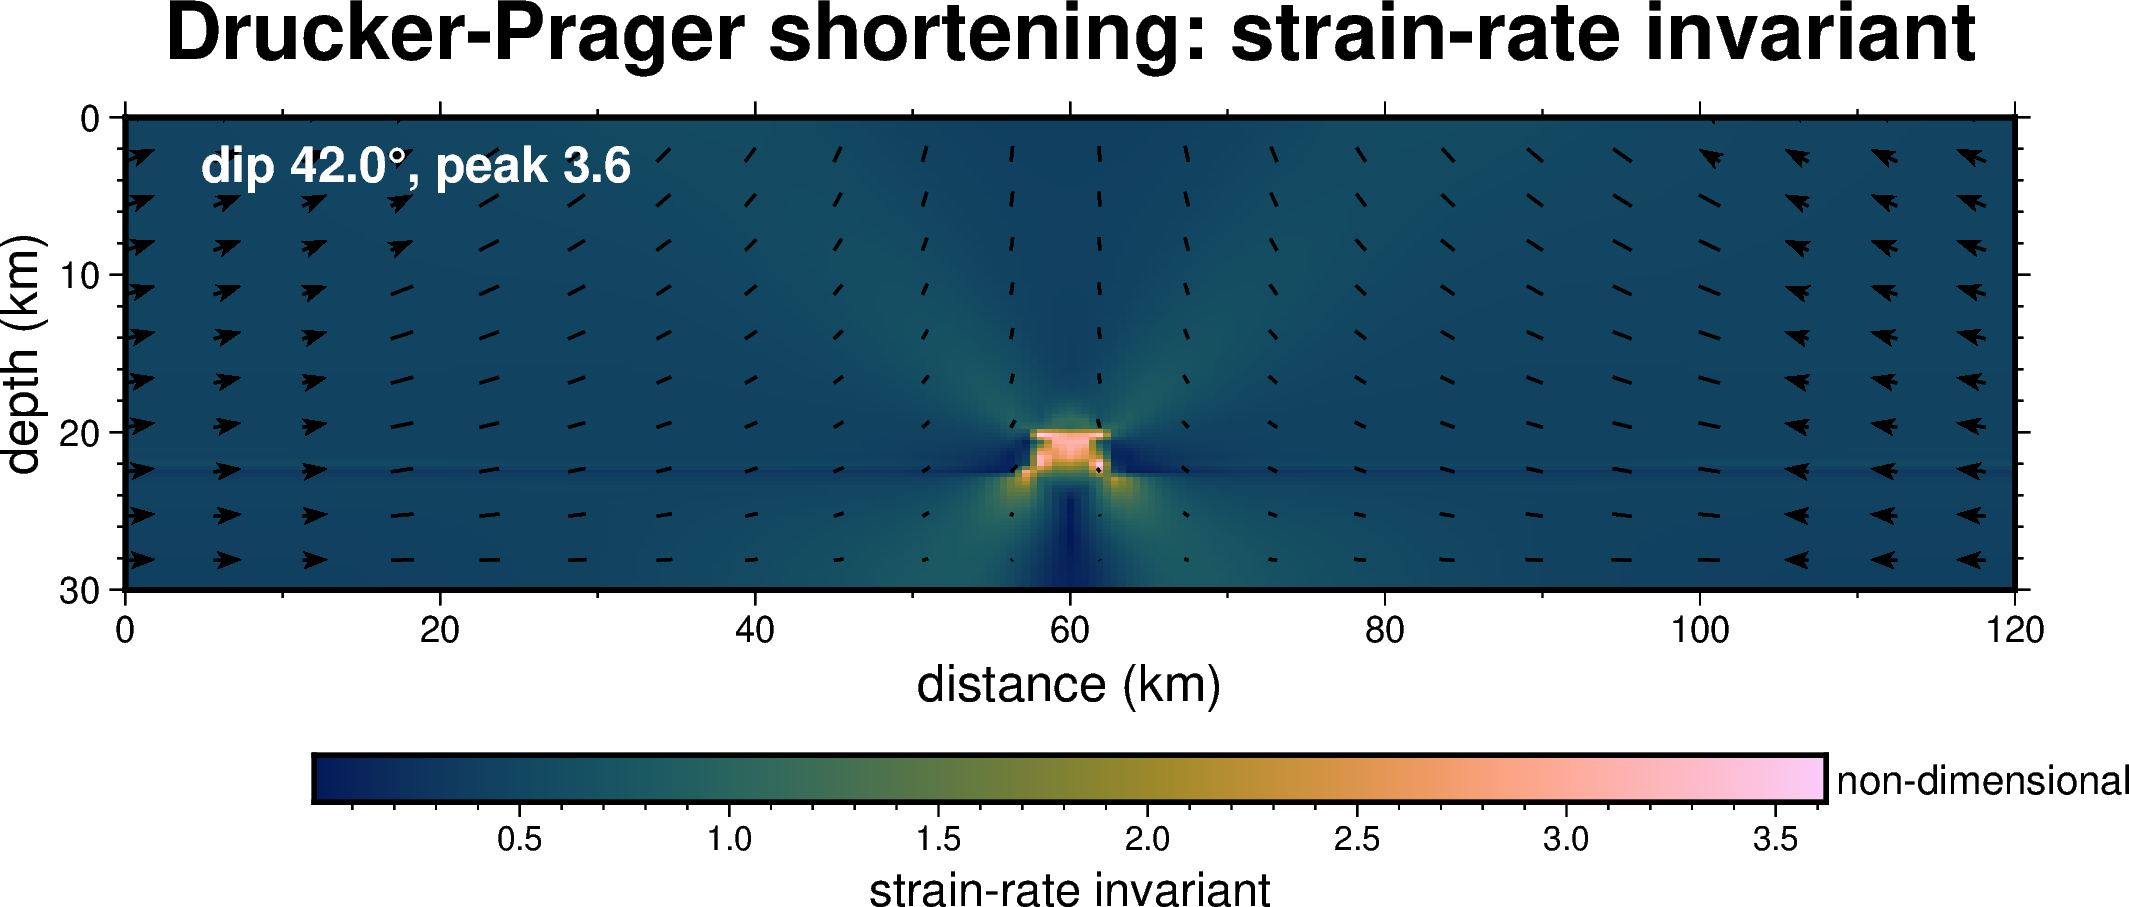

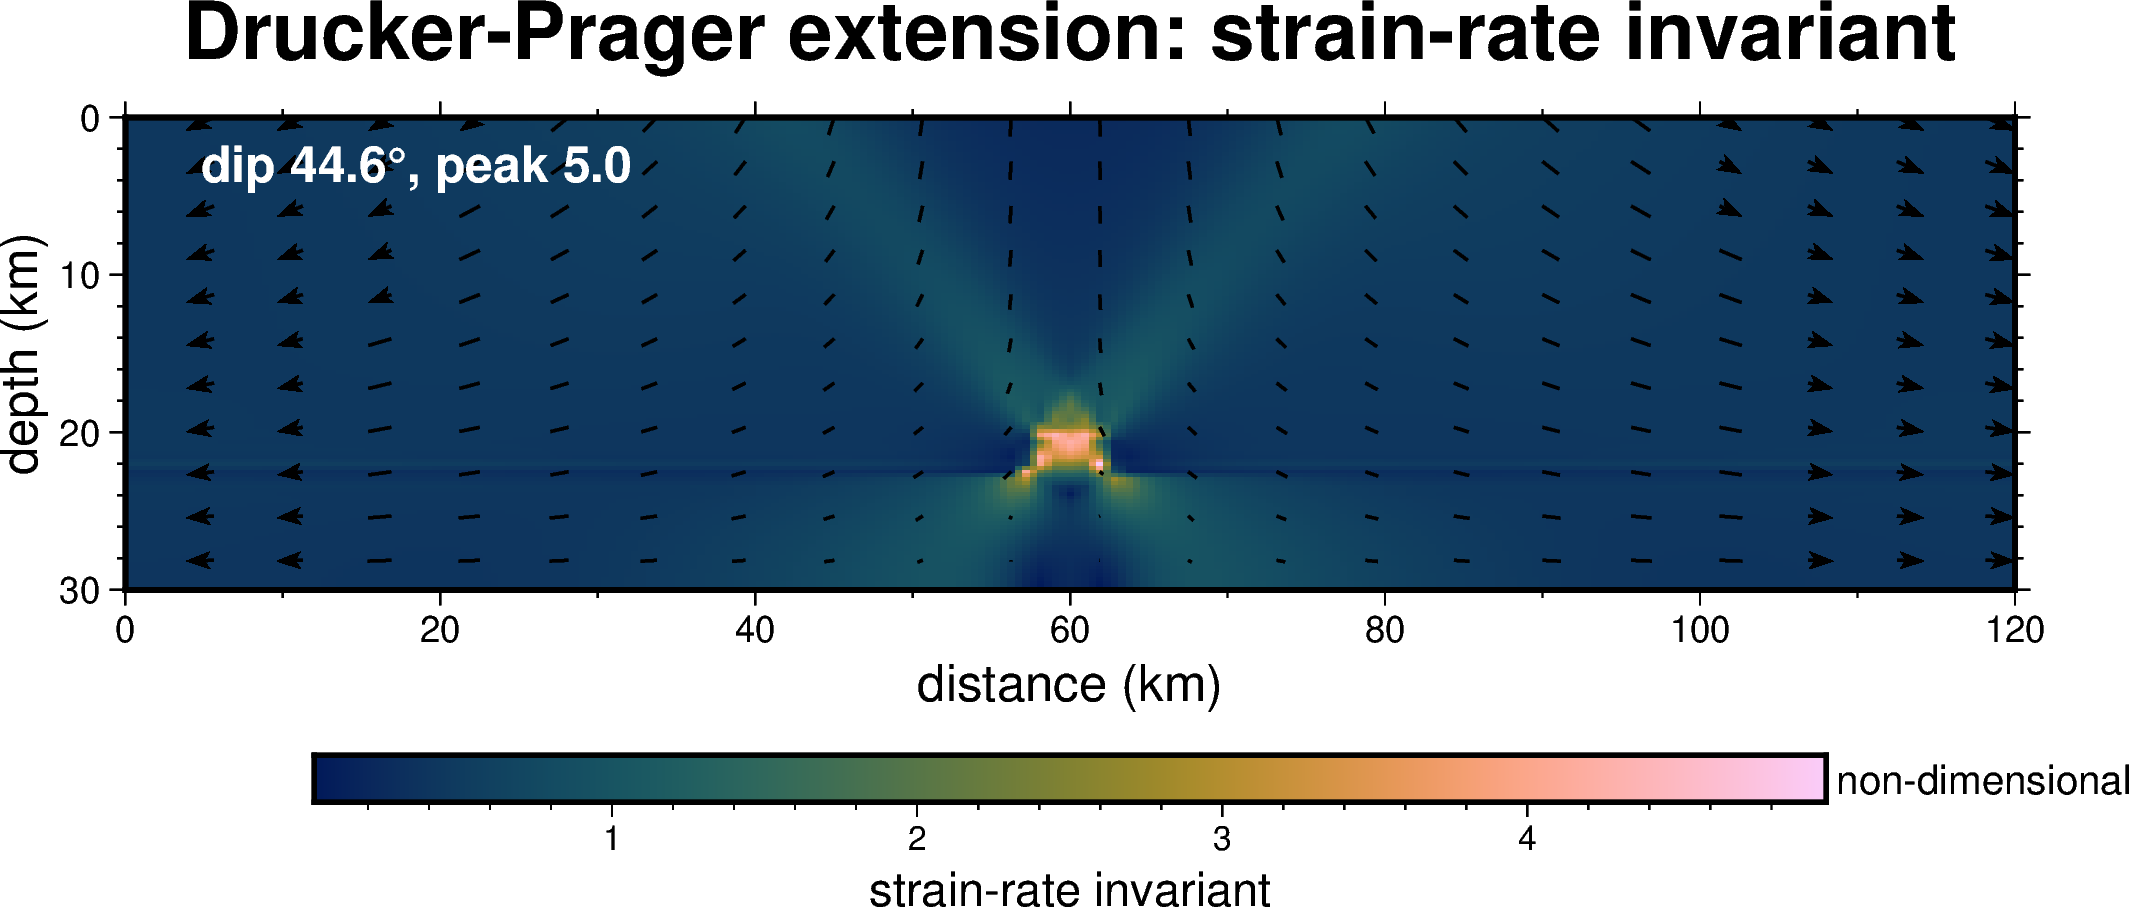

In [4]:
for mode in ("shortening", "extension"):
    d = np.load(f"{OUT}_{mode}_{NX}.npz")
    fig = plotting.field_panel(
        d["strain_rate"], d["x_km"], d["depth_km"], kind="strain_rate",
        title=f"Drucker-Prager {mode}: strain-rate invariant",
        label="strain-rate invariant", unit="non-dimensional",
        vx=d["vx"], vz=d["vz"], every=ARROW_EVERY,
        stamp=f"dip {res[mode]['band_dip_deg']}@., peak {res[mode]['strain_rate_max']:.1f}",
        width_cm=16.0,
    )
    fig.show()

Two conjugate bands rise from the notch to the surface in both cases. The
extensional pair is narrower and carries a higher peak — worth remembering when
we come to ask why rifts are narrow.

The viscosity field says the same thing from the other side: the bands are where
the strong layer has been dragged down towards the substrate's strength.

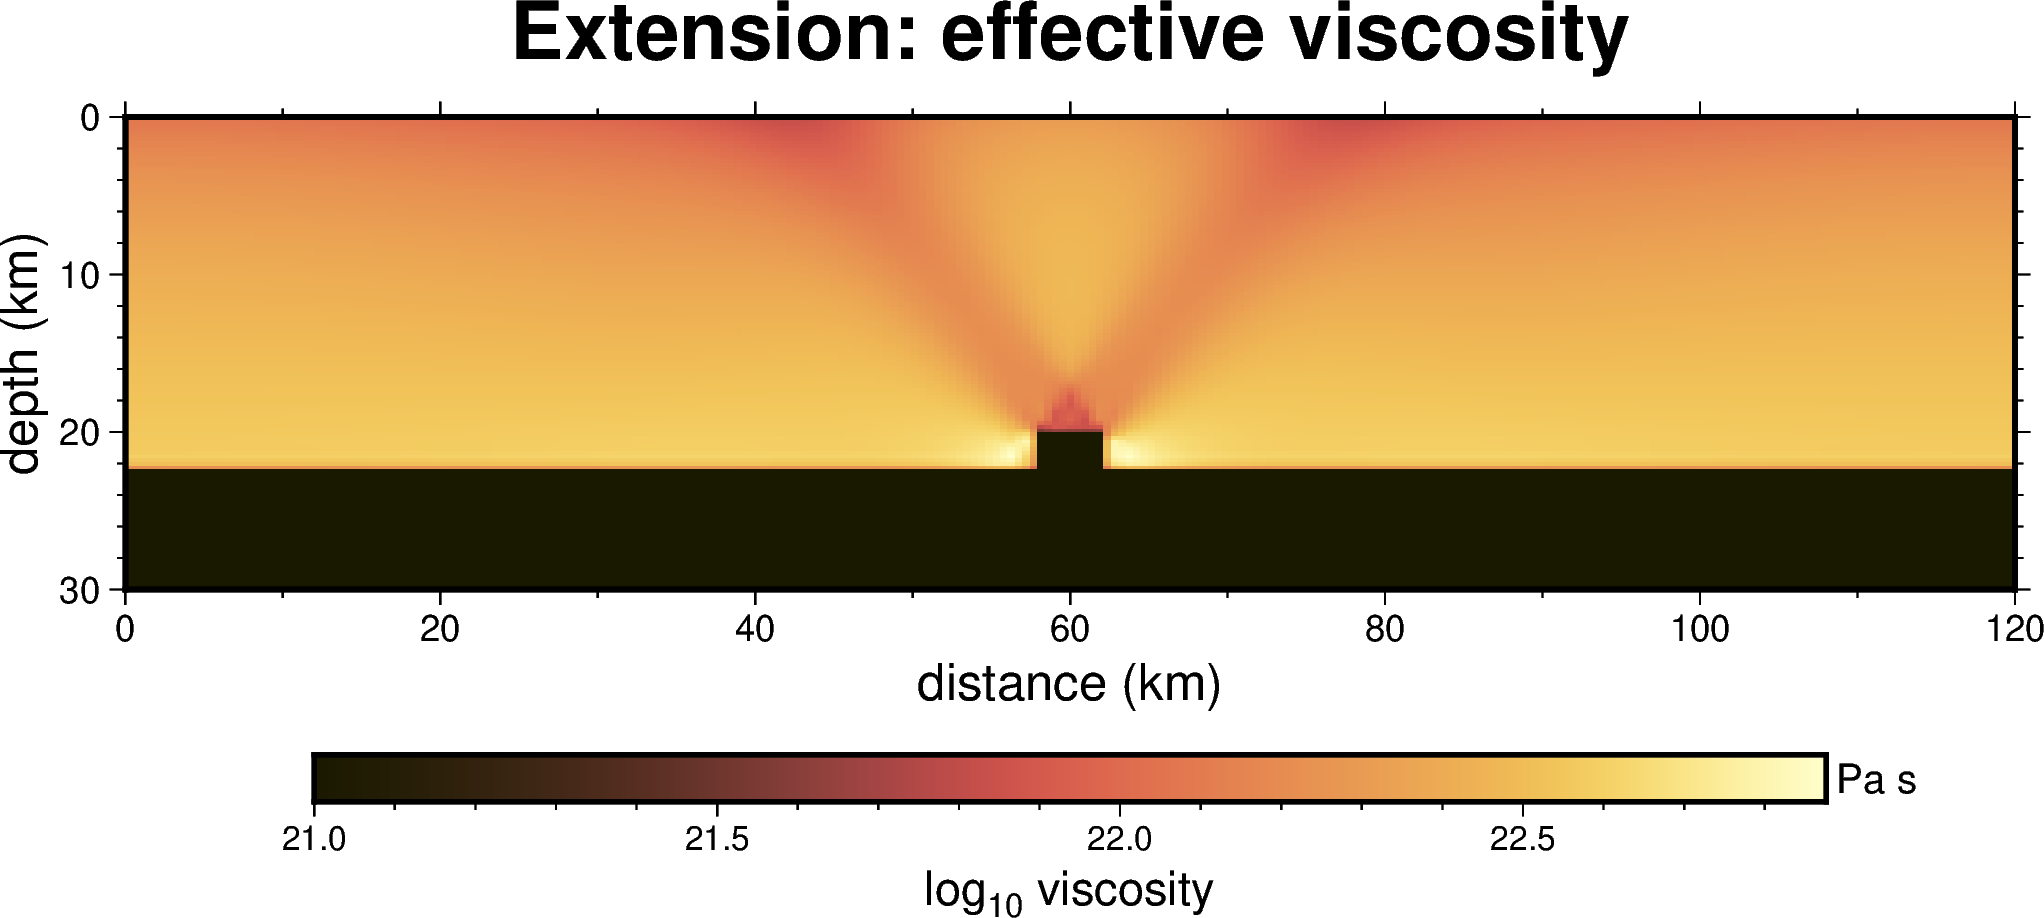

In [5]:
d = np.load(f"{OUT}_extension_{NX}.npz")
fig = plotting.field_panel(
    np.log10(d["viscosity"] * 1e22), d["x_km"], d["depth_km"], kind="viscosity",
    title="Extension: effective viscosity", label="log@-10@- viscosity", unit="Pa s",
    width_cm=16.0,
)
fig.show()

## 5. Verification: at what angle does a shear band form?

Here is a genuine prediction to test. Classical soil mechanics gives three
candidate dips for a band in a material with friction angle $\phi$ and
**dilatancy angle** $\psi$ — how much the material has to expand in order to
shear:

| | angle | value here ($\phi = 30°$, $\psi = 0$) | reasoning |
|---|---|---|---|
| **Coulomb** | $45° - \phi/2$ | 30.0° | plane of maximum stress obliquity |
| **Roscoe** | $45° - \psi/2$ | 45.0° | plane of zero extension — kinematic |
| **Arthur** | $45° - (\phi+\psi)/4$ | 37.5° | empirical compromise |

Our model is **non-dilatant** ($\psi = 0$): the flow is incompressible, so the
material shears without expanding. On the kinematic argument it should therefore
pick the Roscoe angle, and it has no reason to pick Coulomb. Let us look.

In [6]:
print(f"{'mode':>11} {'measured dip':>13}   (Coulomb 30.0, Roscoe 45.0, Arthur 37.5)")
for m, r in res.items():
    print(f"{m:>11} {r['band_dip_deg']:>11.1f} deg")

       mode  measured dip   (Coulomb 30.0, Roscoe 45.0, Arthur 37.5)
 shortening        42.0 deg
  extension        44.6 deg


Extension lands on **45°**, essentially exactly Roscoe. Shortening lands near
**42°**, between Arthur and Roscoe and nowhere near Coulomb.

This is the right kind of check. It is a *geometric* property of the solution,
predicted independently of the code by a century-old argument, and it does not
care how big the numbers in the output happen to be. Compare that with the
temptation to quote the peak strain rate — which is where the next section goes.

The shortening result sitting a few degrees below Roscoe is itself informative:
the incompressibility that makes $\psi = 0$ is enforced weakly, by a pressure
multiplier on a Q2/Q1 element, not pointwise. A small amount of numerical
dilatancy survives, and it pushes the angle the way the theory says it should.

## 6. What converges, and what only looks like a result

Now refine the mesh and watch four diagnostics.

In [7]:
rows = []
for mode in ("shortening", "extension"):
    for nx in SWEEP:
        r = run(mode, nx=nx)
        rows.append((mode, nx, r["cell_width_km"], r["strain_rate_max"],
                     r["strain_rate_median"], r["band_dip_deg"], r["band_width_km"]))

# Values for 192 and 256 measured when this notebook was written; re-run the
# driver yourself if you want them live (256 takes about 95 s per mode).
QUOTED = [("shortening", 192, 0.625, 6.124, 0.478, 41.8, 13.438),
          ("shortening", 256, 0.469, 4.927, 0.478, 41.8, 13.125),
          ("extension", 192, 0.625, 7.973, 0.444, 45.4, 9.375),
          ("extension", 256, 0.469, 6.851, 0.444, 45.1, 9.375)]

table = sorted(rows + QUOTED, key=lambda t: (t[0], t[1]))
print(f"{'mode':>11} {'nx':>4} {'cell km':>8} {'peak':>7} {'median':>7} "
      f"{'dip':>6} {'FWHM km':>8}")
for t in table:
    print(f"{t[0]:>11} {t[1]:>4} {t[2]:>8.3f} {t[3]:>7.3f} {t[4]:>7.3f} "
          f"{t[5]:>6.1f} {t[6]:>8.2f}")

       mode   nx  cell km    peak  median    dip  FWHM km
  extension   64    1.875   3.673   0.451   42.9    10.31
  extension  128    0.938   4.979   0.445   44.6     9.38
  extension  192    0.625   7.973   0.444   45.4     9.38
  extension  256    0.469   6.851   0.444   45.1     9.38
 shortening   64    1.875   2.932   0.481   38.2    14.06
 shortening  128    0.938   3.620   0.478   42.0    13.59
 shortening  192    0.625   6.124   0.478   41.8    13.44
 shortening  256    0.469   4.927   0.478   41.8    13.12


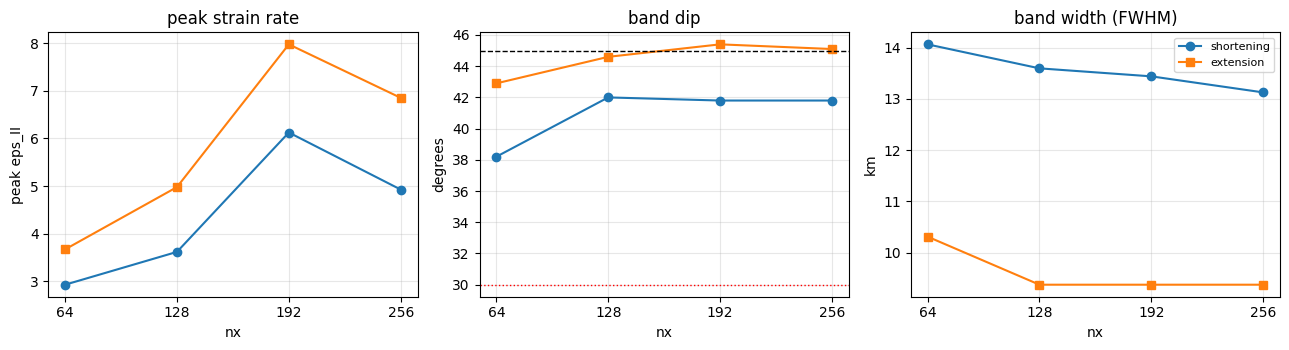

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for mode, mk in (("shortening", "o-"), ("extension", "s-")):
    sub = [t for t in table if t[0] == mode]
    n = [t[1] for t in sub]
    ax[0].plot(n, [t[3] for t in sub], mk, label=mode)
    ax[1].plot(n, [t[5] for t in sub], mk, label=mode)
    ax[2].plot(n, [t[6] for t in sub], mk, label=mode)
for a, ttl, yl in zip(ax, ("peak strain rate", "band dip", "band width (FWHM)"),
                      ("peak eps_II", "degrees", "km")):
    a.set(xlabel="nx", ylabel=yl, title=ttl)
    a.set_xticks([64, 128, 192, 256])
    a.grid(alpha=0.3)
ax[1].axhline(45, color="k", ls="--", lw=1)
ax[1].axhline(30, color="r", ls=":", lw=1)
ax[2].legend(fontsize=8)
fig.tight_layout()
plt.show()

Read the three panels in order, because they say three different things.

**Peak strain rate does not converge.** It goes 2.93, 3.62, 6.12, 4.93 in
shortening and 3.67, 4.98, 7.97, 6.85 in extension — it does not settle, and it
is not even monotone. The 192 case is the outlier in both, and there is a reason:
at nx = 192 the 5 km notch happens to land exactly on cell boundaries, while at
64, 128 and 256 it straddles them. The sharpest seed gives the sharpest band. So
the peak is partly reporting *how the seed geometry happens to align with the
mesh*. **Never quote a peak strain rate from a localisation model without a
resolution study**, and be suspicious of one even then.

**The background is rock-solid.** The median strain rate is 0.478 in every
shortening run and 0.444 in every extension run, to three digits, across a
four-fold refinement. The bulk flow is converged; only the extremum is not. This
is the general shape of the problem — refinement buys you the field, not its
maximum.

**The dip converges.** 38.2 → 42.0 → 41.8 → 41.8 and 42.9 → 44.6 → 45.4 → 45.1.
The verification in section 5 is therefore a real one; it would still be true on
a finer mesh.

**And the band width converges too** — 10.31, 9.38, 9.38, 9.38 km in extension,
while the cell shrinks from 1.875 to 0.469 km. That may be the most surprising
line in the table, because Drucker–Prager plasticity is famous for having *no*
length scale, and the standard expectation is a band that thins towards the cell
size forever. Something is holding it open. The next section finds out what.

## 7. What sets the width of a shear band here?

There are two usual suspects, and it is neither of them.

**Not the viscosity floor.** The driver bounds the yielded viscosity below, and a
lower bound is a length scale in disguise. But dropping it from $10^{21}$ to
$3\times10^{19}$ Pa s changes the answer not by one digit in any diagnostic — the
floor never binds. Try it: `run("extension", visc_floor=3e19)`.

**Not the mesh**, as the table just showed.

**It is the seed.** Widen the notch and the band widens with it:

In [9]:
notch = [run("extension", nx=NOTCH_NX, notch_km=w) for w in (2.5, 5, 10, 20)]
print(f"{'notch km':>9} {'FWHM km':>8} {'peak':>7} {'dip':>6}")
for r in notch:
    print(f"{r['notch_km']:>9.1f} {r['band_width_km']:>8.2f} "
          f"{r['strain_rate_max']:>7.2f} {r['band_dip_deg']:>6.1f}")

 notch km  FWHM km    peak    dip
      2.5     8.91    5.31   44.6
      5.0     9.38    4.98   44.6
     10.0    11.25    4.51   47.6
     20.0    13.59    3.45   50.4


Eight-fold the seed and the band widens by about half, while the peak strain rate
falls by a third. The band remembers where it came from.

The reason is that this solve is **instantaneous**, and the rheology has no
memory. A band forms because the notch perturbs the stress field, but nothing
rewards it for having formed: on the next solve the material is exactly as strong
as it was before. There is no positive feedback, so nothing drives the band to
collapse to the smallest scale available, and the width settles at whatever the
seed and the layer thickness dictate.

That is a comfortable place to be numerically, and a misleading one physically.
Real faults *do* remember. Slip damages rock, damaged rock is weaker, and weaker
rock takes the next increment of slip too. Modelling that means **strain
weakening** — reducing cohesion and friction as accumulated plastic strain grows —
and strain weakening needs a *time-dependent* model, because there is nothing to
accumulate in a single solve.

The moment you add it, everything in this notebook that was well behaved stops
being so: the feedback loop closes, the band does start collapsing towards the
mesh scale, and the width you measure becomes a statement about your resolution
rather than about the rock. That is the subject of the next notebook, and it is
the reason this one spent so long on which diagnostics can be trusted.

## Extend this

* Change the friction angle to 15° and 45°. Does the measured dip track Coulomb ($45° - \phi/2$) or stay at Roscoe? The answer is a real result about non-associated plasticity.
* Set the cohesion to zero. Where does the band nucleate when there is no strength at zero pressure?
* Time the Picard ladder with and without the isoviscous warm-up. How does it fail without it, and does the error message tell you why?
* Run the extension case at nx = 384 and add the point to the three panels. Does the peak strain rate ever settle?
* Put the notch off-centre. Do the conjugate bands stay symmetric?

**Next:** T10 makes the model time-dependent — material advection, accumulated
plastic strain and strain weakening — and turns this benchmark into a rift.